# Lab - Exploração Inicial

> JupyterLab configurations

In [1]:
%xmode plain

Exception reporting mode: Plain


In [2]:
import pandas as pd

pd.options.display.float_format = "{:.2f}".format

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import ConnectionPatch

In [4]:
import time

In [5]:
import os

In [6]:
from pathlib import Path

In [7]:
from IPython.core.interactiveshell import InteractiveShell

InteractiveShell.ast_node_interactivity = "all"

In [37]:
import json
import pprint

In [34]:
from util import cron

> `jupysql` configurations

In [8]:
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = True
%config SqlMagic.displaycon = True

> `duckdb` configurations

In [9]:
import duckdb
import pandas as pd

conn = duckdb.connect()
conn.execute("SET threads = 15")
conn.execute("SET memory_limit = '30GB'")

In [10]:
conn.sql("""
    SELECT name, value
    FROM duckdb_settings()
    WHERE name IN (
      'threads', 'memory_limit'
    )
""").show()

┌──────────────┬──────────┐
│     name     │  value   │
│   varchar    │ varchar  │
├──────────────┼──────────┤
│ memory_limit │ 27.9 GiB │
│ threads      │ 15       │
└──────────────┴──────────┘



## Tamanho

In [11]:
from pathlib import Path

PAR_LAB = Path("Parquet/lab_events.parquet")    # ~2GB
f"{PAR_LAB.stat().st_size / 2 ** 30 :.2f} GiB"

'2.43 GiB'

## Estrutura

In [12]:
conn.sql(f"""
SELECT column_name, column_type
FROM (
    DESCRIBE SELECT *
    FROM '{PAR_LAB}'
)
""").show()

┌─────────────┬────────────────────┐
│ column_name │    column_type     │
│   varchar   │      varchar       │
├─────────────┼────────────────────┤
│ _index      │ VARCHAR            │
│ _type       │ VARCHAR            │
│ _id         │ VARCHAR            │
│ _score      │ BIGINT             │
│ _source     │ MAP(VARCHAR, JSON) │
└─────────────┴────────────────────┘



A complexidade está todas nos eventos em `_source`

In [14]:
total_linhas_lab = conn.sql(f"SELECT COUNT(*) FROM '{PAR_LAB}'").fetchone()[0]
print(f"{total_linhas_lab = :_}")

total_linhas_lab = 49_914_325


> Criar uma view pra não ficar repetindo o caminho

In [15]:
conn.execute(f"""
CREATE OR REPLACE VIEW lab AS
SELECT * FROM read_parquet('{PAR_LAB}')
""")

Agora fica um tico mais legíveis as queries (pode usar só `lab`)

In [18]:
conn.sql("SELECT column_name, column_type FROM (DESCRIBE lab)")

┌─────────────┬────────────────────┐
│ column_name │    column_type     │
│   varchar   │      varchar       │
├─────────────┼────────────────────┤
│ _index      │ VARCHAR            │
│ _type       │ VARCHAR            │
│ _id         │ VARCHAR            │
│ _score      │ BIGINT             │
│ _source     │ MAP(VARCHAR, JSON) │
└─────────────┴────────────────────┘

> ⚠️ `_source` não tem estrutura homogênea. Tem muitas chaves diferentes

## Datapoint Normal

In [43]:
lab_df_example_datapoint = conn.sql("SELECT * FROM lab LIMIT 1").df()
lab_df_example_datapoint

,_index,_type,_id,_score,_source
0,logs-endpoint-winevent-additional-2022.11.16,_doc,8c0acd213cc3524fc717afbc33644d9c2eb6626c,1,"{'event_original_time': '""2022-11-16T08:25:38...."


In [45]:
lab_json_example_datapoint = json.loads(
    lab_df_example_datapoint["_source"].to_json()
)["0"] 
pprint.pprint(lab_json_example_datapoint, sort_dicts=True)

{'@timestamp': '"2022-11-16T08:25:38.047Z"',
 '@version': '"1"',
 'ClientMachine': '"DESKTOP-4PVPS6E"',
 'ClientProcessId': '"4264"',
 'Component': '"Unknown"',
 'Id': '"{00000000-0000-0000-0000-000000000000}"',
 'Operation': '"Start IWbemServices::ExecQuery - root\\\\CIMV2 : SELECT uuid '
              'FROM win32_computersystemproduct "',
 'PossibleCause': '"Unknown"',
 'ResultCode': '"0x80041032"',
 'User': '"nt authority\\\\system"',
 'beat_name': '"DESKTOP-4PVPS6E"',
 'beat_version': '"8.5.0"',
 'etl_host_agent_ephemeral_uid': '"f7b6d19e-5167-4483-b795-09a22efb4701"',
 'etl_host_agent_type': '"winlogbeat"',
 'etl_host_agent_uid': '"f99bee41-708a-4aa2-ad36-b5a565e36b68"',
 'etl_pipeline': '["all-filter-0098","all-add_processed_timestamp","fingerprint-winlogbeats7","winlogbeat_7_and_above-field_nest_cleanup","winlogbeat_7_and_above-field_cleanups","1500","1522","wmi-user_field_renames","wmi-all-extract_domain_and_user_name","general_rename-various_global_options","provider_guid-clea

## Datapoint Malicioso

Os maliciosos estão associados ao MITRE ATT&CK

In [35]:
with cron(f"contar maliciosos no LAB"):
    lab_df_count_malicious = conn.sql("""
        SELECT COUNT(*) AS maliciosos
        FROM lab
        WHERE _source['rule_technique_id'] IS NOT NULL
    """).df()
    
    lab_df_count_malicious.style.format({"maliciosos": "{:_}"})

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,maliciosos
0,1_713_709


[tempo] contar maliciosos no LAB: 51.1s


In [36]:
lab_df_example_malicious_datapoint = conn.sql("""
    SELECT *
    FROM lab
    WHERE _source['rule_technique_id'] IS NOT NULL
    LIMIT 1
""").df()

In [46]:
lab_json_example_malicious_datapoint = json.loads(
    lab_df_example_malicious_datapoint["_source"].to_json()
)["0"]
pprint.pprint(lab_json_example_malicious_datapoint, sort_dicts=True)

{'@timestamp': '"2022-11-16T19:59:51.007Z"',
 '@version': '"1"',
 'EventType': '"CreateKey"',
 'RuleName': '"technique_id=T1553.004,technique_name=Install Root Certificate"',
 'TargetObject': '"HKU\\\\S-1-5-21-1311114680-1922563338-3976463898-1001\\\\SOFTWARE\\\\Microsoft\\\\SystemCertificates\\\\Root\\\\Certificates"',
 'beat_name': '"DESKTOP-4PVPS6E"',
 'beat_version': '"8.5.0"',
 'etl_host_agent_ephemeral_uid': '"ecc16bcb-39c4-4de0-b10a-ed3c7d9bf3c3"',
 'etl_host_agent_type': '"winlogbeat"',
 'etl_host_agent_uid': '"f99bee41-708a-4aa2-ad36-b5a565e36b68"',
 'etl_pipeline': '["all-filter-0098","all-add_processed_timestamp","fingerprint-winlogbeats7","winlogbeat_7_and_above-field_nest_cleanup","winlogbeat_7_and_above-field_cleanups","1500","1522","winevent-sysmon-all-1531","sysmon-all-extract_domain_and_user_name","general_rename-various_global_options","general_rename-ProcessGuid","general_rename-ProcessId","general_rename-Image","split-process_path-grok-process_name","provider_guid-c

## Chaves presentes no mapa chave-valor

### Tabela `lab_field_presence`

In [23]:
conn.execute(f"""
CREATE OR REPLACE TABLE lab_field_presence AS
WITH campos_expandidos AS (
    SELECT unnest(map_keys(_source)) AS campo
    FROM lab
),
agregado AS (
    SELECT
        campo,
        COUNT(*) AS n_eventos
    FROM campos_expandidos
    GROUP BY campo
)
SELECT
    campo,
    n_eventos,
    printf('%,d', n_eventos) AS n_eventos_fmt,

    -- percentual com precisão alta
    CAST(100 * n_eventos AS DECIMAL(18,5)) / {total_linhas_lab} AS percentual_raw,

    -- versão arredondada só pra leitura
    round(
        CAST(100 * n_eventos AS DECIMAL(18,5)) / {total_linhas_lab}, 2
    ) AS percentual

FROM agregado
ORDER BY n_eventos DESC, campo
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

### Salvando-a em disco

In [24]:
conn.execute("""
COPY lab_field_presence
TO 'Comiset23_Lab_Dataset/lab_field_presence.csv'
(FORMAT CSV)
""")

### Campos e suas presenças

In [25]:
conn.sql("""
SELECT campo, n_eventos_fmt, percentual, percentual_raw
FROM lab_field_presence
ORDER BY n_eventos DESC
""").show(max_rows=1500)

┌─────────────────────────────────────────────────────────────────────┬───────────────┬────────────┬────────────────────────┐
│                                campo                                │ n_eventos_fmt │ percentual │     percentual_raw     │
│                               varchar                               │    varchar    │   double   │         double         │
├─────────────────────────────────────────────────────────────────────┼───────────────┼────────────┼────────────────────────┤
│ @timestamp                                                          │ 49,914,325    │      100.0 │                  100.0 │
│ @version                                                            │ 49,914,325    │      100.0 │                  100.0 │
│ beat_version                                                        │ 49,914,325    │      100.0 │                  100.0 │
│ etl_host_agent_ephemeral_uid                                        │ 49,914,325    │      100.0 │                  

### Anotando categorias semânticas

Claude ajudou a separar, dados os 1,293 campos

In [26]:
result = conn.sql("""
    SELECT
        campo,
        n_eventos_fmt,
        percentual,
        CASE
            WHEN campo IN ('@timestamp','event_original_time','event_recorded_time','event_timezone') 
                THEN 'tempo'
            WHEN campo IN ('event_id','log_name','source_name','level','opcode','record_number','version','task','xml_name') 
                THEN 'evento_windows'
            WHEN campo IN ('process_name','process_path','process_id','process_guid','process_parent_name',
                           'process_parent_path','process_parent_id','process_parent_guid',
                           'target_process_name','target_process_path','target_process_id','target_process_guid',
                           'CommandLine','ParentCommandLine','CurrentDirectory','IntegrityLevel',
                           'ProcessCreationTime','CallTrace','GrantedAccess','SourceThreadId',
                           'StartAddress','StartModule','StartFunction','NewThreadId') 
                THEN 'processo'
            WHEN campo IN ('user_name','user_domain','user_account','user_sid','user_logon_id',
                           'meta_user_name_is_machine','LogonId','LogonGuid','logon_type',
                           'SubjectUserName','SubjectDomainName','SubjectUserSid','SubjectLogonId',
                           'TargetUserName','TargetDomainName','TargetUserSid','TargetLogonId',
                           'AuthenticationPackageName','ElevatedToken','ImpersonationLevel') 
                THEN 'identidade'
            WHEN campo IN ('src_ip_addr','dst_ip_addr','DestinationPort','SourcePort','Protocol',
                           'DestinationHostname','SourceHostname','Initiated','PipeName',
                           'src_ip_public','dst_ip_public','src_ip_rfc','dst_ip_rfc',
                           'QueryName','QueryResults','QueryStatus') 
                THEN 'rede'
            WHEN campo IN ('TargetFilename','file_creation_time','file_previous_creation_time',
                           'TargetObject','EventType','Details','ImageLoaded',
                           'hash_md5','hash_sha1','hash_sha256','hash_imphash',
                           'Signature','SignatureStatus','Signed') 
                THEN 'arquivo_registro'
            WHEN campo IN ('rule_technique_id','rule_technique_name','rule_technique','RuleName','RuleId','tags') 
                THEN 'mitre_label'
            WHEN campo IN ('host_name','beat_name','beat_version','provider_guid','thread_id','process_id',
                           'activity_id','keywords') 
                THEN 'host_sistema'
            WHEN campo LIKE 'etl_%' OR campo IN ('@version','z_elastic_ecs','z_logstash_pipeline',
                           'etl_pipeline','etl_version','etl_processed_time','etl_host_agent_type',
                           'etl_host_agent_uid','etl_host_agent_ephemeral_uid','event_original_message') 
                THEN 'etl_infraestrutura'
            WHEN campo LIKE 'param%' OR campo LIKE 'BucketIo%' OR campo LIKE 'Mft%' 
                OR campo LIKE 'LastError_%' OR campo LIKE 'TotalDevice%' OR campo LIKE 'BugcheckP%'
                OR campo LIKE 'LogFileFull%' OR campo LIKE 'MetaData%' OR campo LIKE 'UserDisk%'
                OR campo LIKE 'UserFile%' OR campo LIKE 'UserIndex%' OR campo LIKE 'VolumeTrim%'
                OR campo LIKE 'DeviceQueue%' OR campo LIKE 'BucketIoLatency%' OR campo LIKE 'BucketIoSuccess%'
                THEN 'ruido_hardware'
            ELSE 'outros'
        END AS categoria,
        CASE
            WHEN campo IN ('process_guid','process_parent_guid','target_process_guid',
                           '@timestamp','event_id','host_name','rule_technique_id','rule_technique_name',
                           'user_name','process_name','CommandLine','LogonId') 
                THEN true ELSE false
        END AS pm_core,
        CASE
            WHEN campo IN ('rule_technique_id','rule_technique_name','event_id','host_name',
                           'process_name','process_path','user_name','user_domain',
                           'CommandLine','src_ip_addr','dst_ip_addr','DestinationPort',
                           'hash_md5','hash_sha256','IntegrityLevel','logon_type',
                           'TargetFilename','CallTrace','GrantedAccess') 
                THEN true ELSE false
        END AS ml_feature
    FROM lab_field_presence
    ORDER BY
        CASE categoria
            WHEN 'mitre_label'       THEN 1
            WHEN 'processo'          THEN 2
            WHEN 'identidade'        THEN 3
            WHEN 'rede'              THEN 4
            WHEN 'arquivo_registro'  THEN 5
            WHEN 'tempo'             THEN 6
            WHEN 'evento_windows'    THEN 7
            WHEN 'host_sistema'      THEN 8
            WHEN 'outros'            THEN 9
            WHEN 'etl_infraestrutura' THEN 10
            WHEN 'ruido_hardware'    THEN 11
        END,
        percentual DESC
""")

result.write_csv("Comiset23_Lab_Dataset/lab_field_presence_annotated.csv")
result.show(max_rows=1500)

┌─────────────────────────────────────────────────────────────────────┬───────────────┬────────────┬────────────────────┬─────────┬────────────┐
│                                campo                                │ n_eventos_fmt │ percentual │     categoria      │ pm_core │ ml_feature │
│                               varchar                               │    varchar    │   double   │      varchar       │ boolean │  boolean   │
├─────────────────────────────────────────────────────────────────────┼───────────────┼────────────┼────────────────────┼─────────┼────────────┤
│ RuleName                                                            │ 49,470,758    │      99.11 │ mitre_label        │ false   │ false      │
│ rule_technique_name                                                 │ 1,714,728     │       3.44 │ mitre_label        │ true    │ true       │
│ rule_technique_id                                                   │ 1,713,709     │       3.43 │ mitre_label        │ true    

### Tentando separar em 'bins'

In [27]:
lab_field_presence_bins_semantic = conn.sql("""
SELECT
    campo,
    percentual,
    CASE
        WHEN percentual >= 99 THEN '99–100%'
        WHEN percentual >= 90 THEN '90–99%'
        WHEN percentual >= 50 THEN '50–90%'
        WHEN percentual >= 10 THEN '10–50%'
        WHEN percentual >= 1 THEN '1–10%'
        ELSE '<1%'
    END AS bin,
    n_eventos
FROM lab_field_presence
""").show(max_rows=1500)

┌─────────────────────────────────────────────────────────────────────┬────────────┬─────────┬───────────┐
│                                campo                                │ percentual │   bin   │ n_eventos │
│                               varchar                               │   double   │ varchar │   int64   │
├─────────────────────────────────────────────────────────────────────┼────────────┼─────────┼───────────┤
│ @timestamp                                                          │      100.0 │ 99–100% │  49914325 │
│ @version                                                            │      100.0 │ 99–100% │  49914325 │
│ beat_version                                                        │      100.0 │ 99–100% │  49914325 │
│ etl_host_agent_ephemeral_uid                                        │      100.0 │ 99–100% │  49914325 │
│ etl_host_agent_type                                                 │      100.0 │ 99–100% │  49914325 │
│ etl_host_agent_uid                 

In [28]:
lab_field_presence_bins_semantic_summary = conn.sql("""
SELECT
    CASE
        WHEN percentual >= 99 THEN '99–100%'
        WHEN percentual >= 90 THEN '90–99%'
        WHEN percentual >= 50 THEN '50–90%'
        WHEN percentual >= 10 THEN '10–50%'
        WHEN percentual >= 1 THEN '1–10%'
        ELSE '<1%'
    END AS bin,
    COUNT(*) AS n_campos
FROM lab_field_presence
GROUP BY 1
ORDER BY
    CASE bin
        WHEN '99–100%' THEN 1
        WHEN '90–99%' THEN 2
        WHEN '50–90%' THEN 3
        WHEN '10–50%' THEN 4
        WHEN '1–10%' THEN 5
        ELSE 6
    END
""")

┌─────────┬──────────┐
│   bin   │ n_campos │
│ varchar │  int64   │
├─────────┼──────────┤
│ 99–100% │       32 │
│ 50–90%  │        6 │
│ 10–50%  │        9 │
│ 1–10%   │       27 │
│ <1%     │     1219 │
└─────────┴──────────┘

### Histograma das frequências

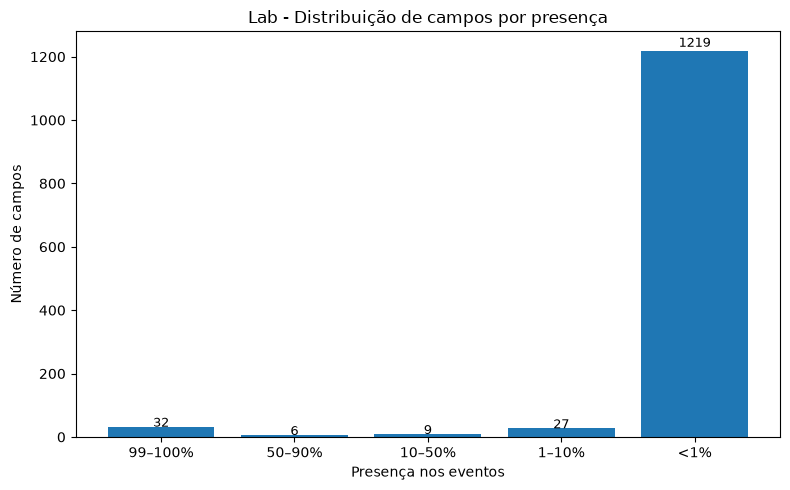

In [29]:
lab_df_field_presence_summary = lab_field_presence_bins_semantic_summary.df()
plt.figure(figsize=(8, 5))
plt.bar(lab_df_field_presence_summary["bin"], lab_df_field_presence_summary["n_campos"])
# plt.yscale('log')  # se quiser deixar um pouco mais aparentes as barras
plt.xlabel("Presença nos eventos")
plt.ylabel("Número de campos")
plt.title("Lab - Distribuição de campos por presença")
for i, v in enumerate(lab_df_field_presence_summary["n_campos"]):
    plt.text(i, v * 1.01, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

---

## Técnicas Presentes

In [30]:
# confirmar os labels MITRE
t0 = time.perf_counter()
result = conn.sql("""
    SELECT
        _source['rule_technique_id']::VARCHAR   AS tecnica_id,
        _source['rule_technique_name']::VARCHAR AS tecnica_nome,
        printf('%,d', COUNT(*)) AS n_fmt,
        COUNT(*) AS n
    FROM lab
    WHERE _source['rule_technique_id'] IS NOT NULL
    GROUP BY 1, 2
    ORDER BY n DESC
""")
result.write_csv("Comiset23_Lab_Dataset/lab_mitre_techniques.csv")
result.show(max_rows=100)
print(f"{time.perf_counter() - t0:.1f}s")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────────────────────────────────────────────────┬─────────────────────────────────────────────────────┬─────────┬────────┐
│                       tecnica_id                        │                    tecnica_nome                     │  n_fmt  │   n    │
│                         varchar                         │                       varchar                       │ varchar │ int64  │
├─────────────────────────────────────────────────────────┼─────────────────────────────────────────────────────┼─────────┼────────┤
│ "T1036"                                                 │ "Masquerading"                                      │ 780,297 │ 780297 │
│ "T1059.001"                                             │ "PowerShell"                                        │ 414,888 │ 414888 │
│ "T1543"                                                 │ "Service Creation"                                  │ 210,198 │ 210198 │
│ "T1574.010"                                             │ "Services

## Distribuição de RuleName

In [31]:
t0 = time.perf_counter()
result = conn.sql("""
    SELECT
        _source['RuleName']::VARCHAR AS rule_name,
        COUNT(*) AS n
    FROM lab
    WHERE _source['RuleName'] IS NOT NULL
    GROUP BY 1
    ORDER BY n DESC
    LIMIT 30
""")
result.write_csv("Comiset23_Lab_Dataset/lab_mitre_rulename_distribution.csv")
result.show(max_rows=50)
print(f"{time.perf_counter() - t0:.1f}s")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬──────────┐
│                                                             rule_name                                                             │    n     │
│                                                              varchar                                                              │  int64   │
├───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼──────────┤
│ "-"                                                                                                                               │ 47646337 │
│ "technique_id=T1036,technique_name=Masquerading"                                                                                  │   780297 │
│ "technique_id=T1059.001,technique_name=PowerShell"                                                                              

## Distribuição de EventID

In [32]:
lab_df_eventid = conn.sql("""
    SELECT
        trim('"' FROM _source['event_id']::VARCHAR)        AS event_id,
        trim('"' FROM _source['log_name']::VARCHAR)        AS canal,
        trim('"' FROM _source['source_name']::VARCHAR)     AS provedor,
        COUNT(*)                                           AS n,
        COUNT(*) FILTER (
            WHERE _source['rule_technique_id'] IS NOT NULL
        )                                                  AS n_maliciosos
    FROM lab
    GROUP BY 1, 2, 3
    ORDER BY n DESC
""").df()

lab_df_eventid["pct"] = (lab_df_eventid["n"] / lab_df_eventid["n"].sum() * 100).round(2)
lab_df_eventid["pct_malicioso"] = (
    lab_df_eventid["n_maliciosos"] / lab_df_eventid["n"] * 100
).round(2)
lab_df_eventid["n_fmt"] = lab_df_eventid["n"].apply(lambda x: f"{x:,}")

print(f"EventIDs únicos: {len(lab_df_eventid)}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

EventIDs únicos: 744


In [33]:
lab_df_eventid

,event_id,canal,provedor,n,n_maliciosos,pct,pct_malicioso,n_fmt
0,12,Microsoft-Windows-Sysmon/Operational,Microsoft-Windows-Sysmon,34832560,121751,69.78,0.35,"34,832,560"
1,10,Microsoft-Windows-Sysmon/Operational,Microsoft-Windows-Sysmon,9963862,70181,19.96,0.70,"9,963,862"
2,11,Microsoft-Windows-Sysmon/Operational,Microsoft-Windows-Sysmon,1602981,155132,3.21,9.68,"1,602,981"
3,3,Microsoft-Windows-Sysmon/Operational,Microsoft-Windows-Sysmon,1197990,1175997,2.40,98.16,"1,197,990"
4,13,Microsoft-Windows-Sysmon/Operational,Microsoft-Windows-Sysmon,1194974,151553,2.39,12.68,"1,194,974"
...,...,...,...,...,...,...,...,...
739,532,Application,ESENT,1,0,0.00,0.00,1
740,12007,Application,Firefox Default Browser Agent,1,0,0.00,0.00,1
741,20502,Microsoft-Windows-TerminalServices-RemoteConne...,Microsoft-Windows-TerminalServices-RemoteConne...,1,0,0.00,0.00,1
742,43,Application,Microsoft-Windows-WMI,1,0,0.00,0.00,1


In [34]:
lab_df_eventid.to_csv("Comiset23_Lab_Dataset/lab_eventid_distribution.csv")

In [35]:
# nomes semânticos dos EventIDs Sysmon + Windows mais comuns
SYSMON_NAMES = {
    "1": "Sysmon 1\nProcess Creation",
    "2": "Sysmon 2\nFile Creation Time",
    "3": "Sysmon 3\nNetwork Connection",
    "5": "Sysmon 5\nProcess Terminated",
    "6": "Sysmon 6\nDriver Loaded",
    "7": "Sysmon 7\nImage Loaded",
    "8": "Sysmon 8\nCreateRemoteThread",
    "9": "Sysmon 9\nRawAccessRead",
    "10": "Sysmon 10\nProcessAccess",
    "11": "Sysmon 11\nFileCreate",
    "12": "Sysmon 12\nRegistry Create/Delete",
    "13": "Sysmon 13\nRegistry SetValue",
    "14": "Sysmon 14\nRegistry Rename",
    "15": "Sysmon 15\nFileCreateStreamHash",
    "17": "Sysmon 17\nPipe Created",
    "18": "Sysmon 18\nPipe Connected",
    "22": "Sysmon 22\nDNS Query",
    "23": "Sysmon 23\nFileDelete",
    "25": "Sysmon 25\nProcessTampering",
    "4624": "WinSec 4624\nLogon Success",
    "4625": "WinSec 4625\nLogon Failure",
    "4688": "WinSec 4688\nProcess Created",
    "4663": "WinSec 4663\nObject Access",
    "5858": "WMI 5858\nQuery Failure",
}

# agrupa: top-N com pct > 0.1%, resto em "outros"
THRESH = 0.1
df_top = lab_df_eventid[lab_df_eventid["pct"] >= THRESH].copy()
df_outros = lab_df_eventid[lab_df_eventid["pct"] < THRESH]

outros_row = {
    "event_id": "outros",
    "provedor": f"{len(df_outros)} event_ids",
    "n": df_outros["n"].sum(),
    "n_maliciosos": df_outros["n_maliciosos"].sum(),
    "pct": df_outros["pct"].sum().round(3),
    "pct_malicioso": (
        df_outros["n_maliciosos"].sum() / df_outros["n"].sum() * 100
    ).round(2),
    "n_fmt": f"{df_outros['n'].sum():,}",
}
lab_df_eventid_plot = pd.concat([df_top, pd.DataFrame([outros_row])], ignore_index=True)

lab_df_eventid_plot["label"] = lab_df_eventid_plot["event_id"].map(
    lambda x: SYSMON_NAMES.get(x, f"EID {x}")
)
lab_df_eventid_plot = lab_df_eventid_plot.sort_values("pct_malicioso", ascending=True)
lab_df_eventid_plot

,event_id,canal,provedor,n,n_maliciosos,pct,pct_malicioso,n_fmt,label
6,23,Microsoft-Windows-Sysmon/Operational,Microsoft-Windows-Sysmon,95305,0,0.19,0.00,"95,305",Sysmon 23\nFileDelete
7,2006,Microsoft-Windows-Store/Operational,Microsoft-Windows-Install-Agent,69797,0,0.14,0.00,"69,797",EID 2006
5,18,Microsoft-Windows-Sysmon/Operational,Microsoft-Windows-Sysmon,397578,107,0.80,0.03,"397,578",Sysmon 18\nPipe Connected
0,12,Microsoft-Windows-Sysmon/Operational,Microsoft-Windows-Sysmon,34832560,121751,69.78,0.35,"34,832,560",Sysmon 12\nRegistry Create/Delete
1,10,Microsoft-Windows-Sysmon/Operational,Microsoft-Windows-Sysmon,9963862,70181,19.96,0.70,"9,963,862",Sysmon 10\nProcessAccess
8,outros,NaN,736 event_ids,559278,38988,0.84,6.97,"559,278",EID outros
2,11,Microsoft-Windows-Sysmon/Operational,Microsoft-Windows-Sysmon,1602981,155132,3.21,9.68,"1,602,981",Sysmon 11\nFileCreate
4,13,Microsoft-Windows-Sysmon/Operational,Microsoft-Windows-Sysmon,1194974,151553,2.39,12.68,"1,194,974",Sysmon 13\nRegistry SetValue
3,3,Microsoft-Windows-Sysmon/Operational,Microsoft-Windows-Sysmon,1197990,1175997,2.40,98.16,"1,197,990",Sysmon 3\nNetwork Connection


In [36]:
mean_pct_malicious = round(lab_df_eventid_plot["pct_malicioso"].mean(), 2)

np.float64(14.29)

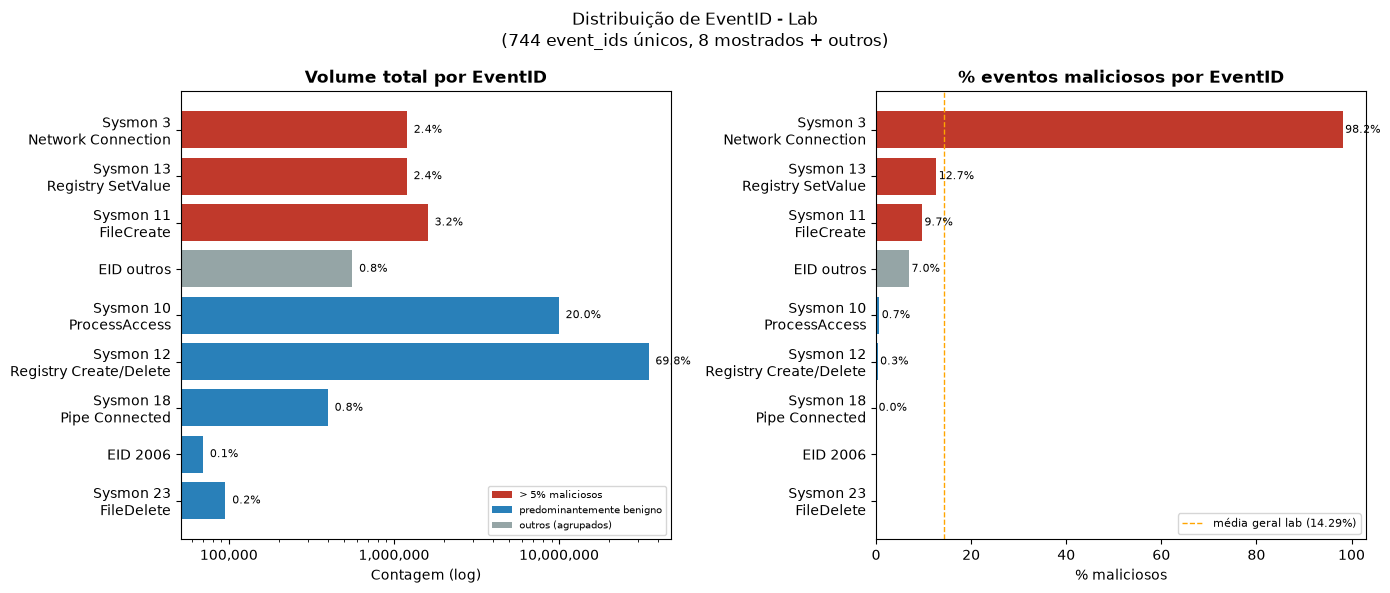

In [37]:
# --- figura ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))


# cores: vermelho se malicioso > 5%, azul normal, cinza = outros
def cor(row):
    if row["event_id"] == "outros":
        return "#95a5a6"
    if row["pct_malicioso"] > 5:
        return "#c0392b"
    return "#2980b9"


colors = [cor(row) for _, row in lab_df_eventid_plot.iterrows()]

# ax1 - volume total
bars = ax1.barh(lab_df_eventid_plot["label"], lab_df_eventid_plot["n"], color=colors)
ax1.set_xscale("log")
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax1.set_title("Volume total por EventID", fontweight="bold")
ax1.set_xlabel("Contagem (log)")
for bar, row in zip(bars, lab_df_eventid_plot.itertuples()):
    ax1.text(
        row.n * 1.1,
        bar.get_y() + bar.get_height() / 2,
        f"{row.pct:.1f}%",
        va="center",
        fontsize=8,
    )

# ax2 - taxa de maliciosidade
bars2 = ax2.barh(
    lab_df_eventid_plot["label"], lab_df_eventid_plot["pct_malicioso"], color=colors
)
ax2.set_title("% eventos maliciosos por EventID", fontweight="bold")
ax2.set_xlabel("% maliciosos")
ax2.axvline(
    x=mean_pct_malicious,
    color="orange",
    linestyle="--",
    lw=1,
    label=f"média geral lab ({mean_pct_malicious}%)",
)
ax2.legend(fontsize=8)
for bar, row in zip(bars2, lab_df_eventid_plot.itertuples()):
    if row.pct_malicioso > 0:
        ax2.text(
            row.pct_malicioso + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f"{row.pct_malicioso:.1f}%",
            va="center",
            fontsize=8,
        )

# legenda de cores
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#c0392b", label="> 5% maliciosos"),
    Patch(facecolor="#2980b9", label="predominantemente benigno"),
    Patch(facecolor="#95a5a6", label="outros (agrupados)"),
]
ax1.legend(handles=legend_elements, fontsize=7, loc="lower right")

plt.suptitle(
    "Distribuição de EventID - Lab\n"
    f"({len(lab_df_eventid)} event_ids únicos, {len(lab_df_eventid_plot) - 1} mostrados + outros)",
    fontsize=12,
)
plt.tight_layout()
plt.savefig("Comiset23_Lab_Dataset/lab_eventid_dist.png", dpi=150, bbox_inches="tight")
plt.show()

## Distribuição de EventType

In [38]:
t0 = time.perf_counter()
result_eventtype_distribution = conn.sql("""
SELECT
    CAST(_source['EventType'] AS VARCHAR),
    COUNT(*) AS n
FROM lab
GROUP BY 1
ORDER BY n DESC
""")
result_eventtype_distribution.write_csv(
    "Comiset23_Lab_Dataset/lab_eventtype_distribution.csv"
)
print(f"{time.perf_counter() - t0:.1f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

80.1


In [39]:
df_eventtype_distribution = result_eventtype_distribution.df()
df_eventtype_distribution.columns = ["event_type", "n"]
df_eventtype_distribution["event_type"] = df_eventtype_distribution[
    "event_type"
].str.strip('"')  # tirando aspas do JSON
df_eventtype_distribution["n_fmt"] = df_eventtype_distribution["n"].apply(
    lambda x: f"{x:,}"
)
df_eventtype_distribution["pct"] = (
    df_eventtype_distribution["n"] / df_eventtype_distribution["n"].sum() * 100
).round(2)
df_eventtype_distribution

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,event_type,n,n_fmt,pct
0,CreateKey,34734002,"34,734,002",69.59
1,NaN,13472163,"13,472,163",26.99
2,SetValue,1194974,"1,194,974",2.39
3,ConnectPipe,397578,"397,578",0.80
4,DeleteKey,61039,"61,039",0.12
5,DeleteValue,37519,"37,519",0.08
6,CreatePipe,17050,"17,050",0.03


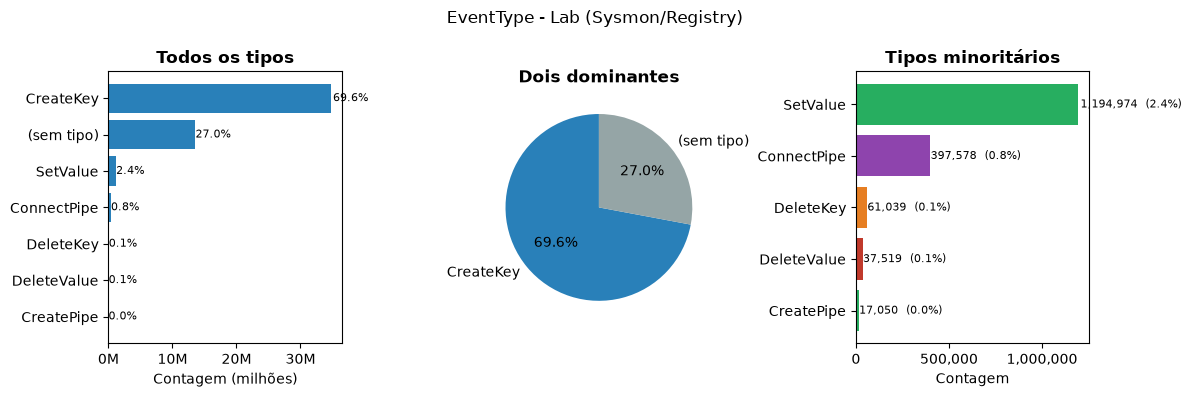

In [40]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

df = df_eventtype_distribution.copy()
df["event_type"] = df["event_type"].fillna("(sem tipo)")

grandes = df[df["event_type"].isin(["CreateKey", "(sem tipo)"])]
pequenos = df[~df["event_type"].isin(["CreateKey", "(sem tipo)"])]

fmt_m = ticker.FuncFormatter(lambda x, _: f"{x / 1e6:.0f}M")

# --- 1. barra geral ---
ax1.barh(df["event_type"], df["n"], color="#2980b9")
ax1.invert_yaxis()
ax1.set_title("Todos os tipos", fontweight="bold")
ax1.set_xlabel("Contagem (milhões)")
ax1.xaxis.set_major_formatter(fmt_m)
for i, row in enumerate(df.itertuples()):
    ax1.text(row.n * 1.01, i, f"{row.pct:.1f}%", va="center", fontsize=8)

# --- 2. pizza com % fixos do df original ---
ax2.pie(
    grandes["n"],
    labels=grandes["event_type"],
    colors=["#2980b9", "#95a5a6"],
    startangle=90,
    autopct=lambda p: f"{p * grandes['n'].sum() / df['n'].sum():.1f}%",
)
ax2.set_title("Dois dominantes", fontweight="bold")

# --- 3. barra minoritários ---
ax3.barh(
    pequenos["event_type"],
    pequenos["n"],
    color=["#27ae60", "#8e44ad", "#e67e22", "#c0392b"],
)
ax3.invert_yaxis()
ax3.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax3.set_title("Tipos minoritários", fontweight="bold")
ax3.set_xlabel("Contagem")
for i, row in enumerate(pequenos.itertuples()):
    ax3.text(row.n * 1.01, i, f"{row.n_fmt}  ({row.pct:.1f}%)", va="center", fontsize=8)

plt.suptitle("EventType - Lab (Sysmon/Registry)", fontsize=12)
plt.tight_layout()
plt.savefig(
    "Comiset23_Lab_Dataset/lab_eventtype_dist.png", dpi=150, bbox_inches="tight"
)
plt.show()

## Distintos aproximados

In [41]:
result_approx_distinct = conn.sql("""
    SELECT
        'lab' AS dataset,
        approx_count_distinct(_source['host_name'])           AS hosts_unicos,
        approx_count_distinct(_source['user_name'])           AS users_unicos,
        approx_count_distinct(_source['event_id'])            AS event_ids_unicos,
        approx_count_distinct(_source['process_name'])        AS processos_unicos,
        approx_count_distinct(_source['rule_technique_id'])   AS tecnicas_mitre,
        approx_count_distinct(_source['log_name'])            AS canais_log,
        approx_count_distinct(_source['process_guid'])        AS sessoes_processo,
        approx_count_distinct(_source['user_account'])        AS contas_unicas,
        approx_count_distinct(_source['src_ip_addr'])         AS ips_origem_unicos,
        approx_count_distinct(_source['dst_ip_addr'])         AS ips_destino_unicos
    FROM lab
""")

result_approx_distinct.write_csv("Comiset23_Lab_Dataset/lab_approx_distinct.csv")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [42]:
# transpor fica mais legível que uma linha larga
lab_df_approx_distinct = result_approx_distinct.df().T.reset_index()
lab_df_approx_distinct.columns = ["metrica", "valor"]

# remove a linha 'dataset' que é string
lab_df_approx_distinct = lab_df_approx_distinct[
    lab_df_approx_distinct["metrica"] != "dataset"
]

lab_df_approx_distinct["valor"] = lab_df_approx_distinct["valor"].astype(int)
lab_df_approx_distinct["valor_fmt"] = lab_df_approx_distinct["valor"].apply(
    lambda x: f"{x:,}"
)
lab_df_approx_distinct.sort_values("valor")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,metrica,valor,valor_fmt
1,hosts_unicos,3,3
2,users_unicos,23,23
8,contas_unicas,24,24
5,tecnicas_mitre,53,53
6,canais_log,68,68
9,ips_origem_unicos,197,197
10,ips_destino_unicos,257,257
4,processos_unicos,273,273
3,event_ids_unicos,514,514
7,sessoes_processo,44008,"44,008"


---

## Fatia das primeiras 24 horas

### Intervalo de Tempo

In [43]:
t0 = time.perf_counter()
lab_df_time_range = conn.sql("""
    SELECT
        MIN(TRIM(BOTH '"' FROM _source['@timestamp']::VARCHAR)::TIMESTAMP) AS ts_min,
        MAX(TRIM(BOTH '"' FROM _source['@timestamp']::VARCHAR)::TIMESTAMP) AS ts_max
    FROM lab
""").df()
lab_df_time_range["duracao"] = lab_df_time_range["ts_max"] - lab_df_time_range["ts_min"]
print(f"{time.perf_counter() - t0:.1f}s")
lab_df_time_range

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

89.5s


,ts_min,ts_max,duracao
0,1990-12-18 16:48:25.255,2022-11-25 23:00:01.295,11665 days 06:11:36.040000


Opa, era pra ser `16/NOV/2022 08:25h` até `25/NOV/2022 22:56h`

`@timestamp` e `event_original_time` vêm do relógio do host e podem ter registros zoados

1. distribuição por ano nos três campos de timestamp:

In [44]:
conn.sql("""
    SELECT
        YEAR(TRIM(BOTH '"' FROM _source['@timestamp']::VARCHAR)::TIMESTAMP)          AS ano_at_ts,
        YEAR(TRIM(BOTH '"' FROM _source['event_original_time']::VARCHAR)::TIMESTAMP) AS ano_orig,
        YEAR(TRIM(BOTH '"' FROM _source['etl_processed_time']::VARCHAR)::TIMESTAMP)  AS ano_etl,
        COUNT(*) AS n
    FROM lab
    GROUP BY 1, 2, 3
    ORDER BY n DESC
    LIMIT 20
""").show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌───────────┬──────────┬─────────┬──────────┐
│ ano_at_ts │ ano_orig │ ano_etl │    n     │
│   int64   │  int64   │  int64  │  int64   │
├───────────┼──────────┼─────────┼──────────┤
│      2022 │     2022 │    2022 │ 49913941 │
│      2022 │     2022 │    NULL │      383 │
│      1990 │     1990 │    1990 │        1 │
└───────────┴──────────┴─────────┴──────────┘



2. inspecionar os registros com timestamp ruim

In [45]:
conn.sql("""
    SELECT
        _source['@timestamp']::VARCHAR          AS at_ts,
        _source['event_original_time']::VARCHAR AS orig_time,
        _source['etl_processed_time']::VARCHAR  AS etl_time,
        _source['source_name']::VARCHAR         AS source_name,
        _source['event_id']::VARCHAR            AS event_id
    FROM lab
    WHERE YEAR(TRIM(BOTH '"' FROM _source['@timestamp']::VARCHAR)::TIMESTAMP) < 2020
    LIMIT 10
""").show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────────────────────┬────────────────────────────┬────────────────────────────┬────────────────────────────┬──────────┐
│           at_ts            │         orig_time          │          etl_time          │        source_name         │ event_id │
│          varchar           │          varchar           │          varchar           │          varchar           │ varchar  │
├────────────────────────────┼────────────────────────────┼────────────────────────────┼────────────────────────────┼──────────┤
│ "1990-12-18T16:48:25.255Z" │ "1990-12-18T16:48:25.255Z" │ "1990-12-18T16:49:50.748Z" │ "Microsoft-Windows-Sysmon" │ 3        │
└────────────────────────────┴────────────────────────────┴────────────────────────────┴────────────────────────────┴──────────┘



Menos mal, tem exatamente 1 registro de timestamp zoado

Antes de corrigir o timerange:

In [46]:
lab_ts_min = lab_df_time_range["ts_min"][0]
lab_ts_cutoff_24h = lab_ts_min + pd.Timedelta(hours=24)
print(f"Início:        {lab_ts_min}")
print(f"Corte (24h):   {lab_ts_cutoff_24h}")
print(f"Fim dataset:   {lab_df_time_range['ts_max'][0]}")
print(f"Duração total: {lab_df_time_range['duracao'][0]}")

Início:        1990-12-18 16:48:25.255000
Corte (24h):   1990-12-19 16:48:25.255000
Fim dataset:   2022-11-25 23:00:01.295000
Duração total: 11665 days 06:11:36.040000


Depois de corrigir o timerange:

In [47]:
t0 = time.perf_counter()
lab_df_time_range_clean = conn.sql("""
    SELECT
        MIN(ts(_source['@timestamp'])) AS ts_min,
        MAX(ts(_source['@timestamp'])) AS ts_max
    FROM lab
    WHERE _source['@timestamp']::VARCHAR LIKE '"2022%'
""").df()
lab_df_time_range_clean["duracao"] = (
    lab_df_time_range_clean["ts_max"] - lab_df_time_range_clean["ts_min"]
)
print(f"{time.perf_counter() - t0:.1f}s")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

81.5s


In [48]:
lab_ts_min = lab_df_time_range_clean["ts_min"][0]
lab_ts_cutoff_24h = lab_ts_min + pd.Timedelta(hours=24)
print(f"Início:        {lab_ts_min}")
print(f"Corte (24h):   {lab_ts_cutoff_24h}")
print(f"Fim dataset:   {lab_df_time_range_clean['ts_max'][0]}")
print(f"Duração total: {lab_df_time_range_clean['duracao'][0]}")

Início:        2022-11-16 08:16:54
Corte (24h):   2022-11-17 08:16:54
Fim dataset:   2022-11-25 23:00:01.295000
Duração total: 9 days 14:43:07.295000


---

## Corte do 1º dia

In [49]:
D1_INICIO = "2022-11-16T08:16:54"

t0 = time.perf_counter()
conn.execute(f"""
    COPY (
        SELECT *
        FROM lab
        WHERE strptime(
            trim('"' FROM _source['@timestamp']::VARCHAR),
            '%Y-%m-%dT%H:%M:%S.%gZ'
        ) >= TIMESTAMPTZ '{D1_INICIO}Z'
        AND strptime(
            trim('"' FROM _source['@timestamp']::VARCHAR),
            '%Y-%m-%dT%H:%M:%S.%gZ'
        ) < TIMESTAMPTZ '{D1_INICIO}Z'::TIMESTAMPTZ + INTERVAL '24 hours'
    )
    TO 'Comiset23_Lab_Dataset/lab_d1.parquet'
    (FORMAT PARQUET, CODEC 'ZSTD', COMPRESSION_LEVEL 9)
""")
elapsed = time.perf_counter() - t0

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

185.25352850000036

In [50]:
minutes, seconds = divmod(int(elapsed), 60)
print(
    f"Parquet: {minutes}min{seconds}s - {Path('Comiset23_Lab_Dataset/lab_d1.parquet').stat().st_size / 1e6:.1f} MB"
)

Parquet: 3min5s - 184.9 MB


---

### Quantidade de maliciosos

In [51]:
df_d1_summary = conn.sql("""
    SELECT
        COUNT(*)                                                            AS total,
        COUNT(*) FILTER (WHERE _source['rule_technique_id'] IS NOT NULL)   AS maliciosos,
        COUNT(*) FILTER (WHERE _source['rule_technique_id'] IS NULL)       AS benignos,
        round(100.0 * COUNT(*) FILTER (WHERE _source['rule_technique_id'] IS NOT NULL) / COUNT(*), 3) AS pct_malicioso,
        MIN(strptime(trim('"' FROM _source['@timestamp']::VARCHAR), '%Y-%m-%dT%H:%M:%S.%gZ')) AS ts_inicio,
        MAX(strptime(trim('"' FROM _source['@timestamp']::VARCHAR), '%Y-%m-%dT%H:%M:%S.%gZ')) AS ts_fim
    FROM 'Comiset23_Lab_Dataset/lab_d1.parquet'
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total,maliciosos,benignos,pct_malicioso,ts_inicio,ts_fim
0,3524864,131579,3393285,3.73,2022-11-16 08:16:54,2022-11-16 23:57:42.588


In [52]:
lab_df_d1_label_split = pd.DataFrame(
    {
        "label": ["normal", "malicioso"],
        "n": [int(df_d1_summary["benignos"][0]), int(df_d1_summary["maliciosos"][0])],
        "pct": [
            100 - float(df_d1_summary["pct_malicioso"][0]),
            float(df_d1_summary["pct_malicioso"][0]),
        ],
    }
)

,label,n,pct
0,normal,3393285,96.27
1,malicioso,131579,3.73


### Visualização da contagem

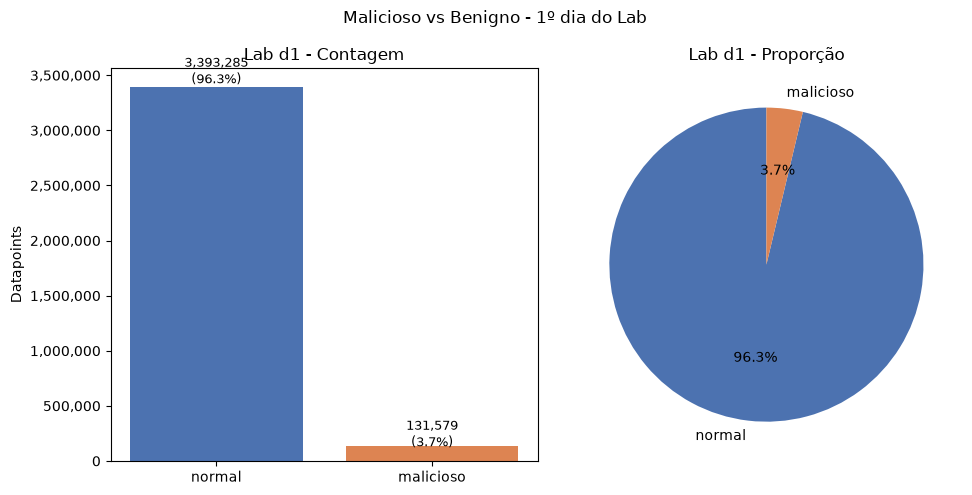

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

labels = ["normal", "malicioso"]
colors = ["#4c72b0", "#dd8452"]

axes[0].bar(labels, lab_df_d1_label_split["n"], color=colors)
axes[0].set_title("Lab d1 - Contagem")
axes[0].set_ylabel("Datapoints")
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for i, (n, pct) in enumerate(
    zip(lab_df_d1_label_split["n"], lab_df_d1_label_split["pct"])
):
    axes[0].text(i, n * 1.01, f"{n:,}\n({pct:.1f}%)", ha="center", fontsize=9)

axes[1].pie(
    lab_df_d1_label_split["n"],
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
)
axes[1].set_title("Lab d1 - Proporção")

plt.suptitle("Malicioso vs Benigno - 1º dia do Lab", fontsize=12)
plt.tight_layout()
plt.savefig(
    "Comiset23_Lab_Dataset/lab_d1_label_split.png", dpi=150, bbox_inches="tight"
)
plt.show()

### Resumo da fatia cortada

In [54]:
df_d1_summary = conn.sql("""
    SELECT
        COUNT(*)                                                                    AS total,
        COUNT(*) FILTER (WHERE _source['rule_technique_id'] IS NOT NULL)            AS maliciosos,
        COUNT(*) FILTER (WHERE _source['rule_technique_id'] IS NULL)                AS benignos,
        round(100.0 * COUNT(*) FILTER (WHERE _source['rule_technique_id'] IS NOT NULL) / COUNT(*), 3) AS pct_malicioso,
        round(100.0 * COUNT(*) FILTER (WHERE _source['rule_technique_id'] IS NULL) / COUNT(*), 3)     AS pct_normal,
        MIN(strptime(trim('"' FROM _source['@timestamp']::VARCHAR), '%Y-%m-%dT%H:%M:%S.%gZ')) AS ts_inicio,
        MAX(strptime(trim('"' FROM _source['@timestamp']::VARCHAR), '%Y-%m-%dT%H:%M:%S.%gZ')) AS ts_fim
    FROM 'Comiset23_Lab_Dataset/lab_d1.parquet'
""").df()

df_d1_summary["total_fmt"] = df_d1_summary["total"].apply(lambda x: f"{x:,}")
df_d1_summary["maliciosos_fmt"] = df_d1_summary["maliciosos"].apply(lambda x: f"{x:,}")
df_d1_summary["benignos_fmt"] = df_d1_summary["benignos"].apply(lambda x: f"{x:,}")

df_d1_summary.T.to_csv("Comiset23_Lab_Dataset/lab_d1_summary.csv", index=True)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [55]:
df_d1_summary.T

,0
total,3524864
maliciosos,131579
benignos,3393285
pct_malicioso,3.73
pct_normal,96.27
ts_inicio,2022-11-16 08:16:54
ts_fim,2022-11-16 23:57:42.588000
total_fmt,"3,524,864"
maliciosos_fmt,"131,579"
benignos_fmt,"3,393,285"


# Fim